# Insurance Claims - Data Processing and Modelling 

<div style="background-color:lightblue; padding:10px;"

## Overview

1. Load packages
2. Preprocessing
3. Label encoding of target (fraud= 1/non-fraud=0)
4. Ordinal Encoding 'incident_severity'
5. Train/Test Split
    - Imbalance and metric
7. Resampling the train set
    - Smote Tomek


## 1. Load packages

In [22]:
#Load standard packages
import pandas as pd
import numpy as np

#Load data vizualization packages
import matplotlib.pyplot as plt

#Load  data processing packages
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek


#Load classifier for modelling
from lazypredict.Supervised import LazyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier

#Load ensemble classifier for modelling
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

#Load packages for model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV


#Load packages for model evaluation
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import joblib

## 2. Preprocessing 

In [23]:
#import
df=pd.read_csv("insurance_claims.csv", parse_dates=["policy_bind_date", "incident_date"], index_col="policy_number")
#check duplicates
print('Duplicated: ', df.duplicated().sum() )
print('\n')
#ensure consistency on column names 
rename ={'capital-gains':'capital_gains','capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)
#Rename Strings from '?' to 'Unkown'
df["collision_type"]=df["collision_type"].apply(lambda x: "No Collision" if str(x)=="?" else x)
df["police_report_available"]=df["police_report_available"].apply(lambda x: "Unknown" if str(x)=="?" else x)
df["property_damage"]=df["property_damage"].apply(lambda x: "Unknown" if str(x)=="?" else x)

# drop column as 100% nan-values
# drop umbrella limits as 80% of values are zeros, std = 1.1 Mio
# drop columns where p_value <5% or highly correlated with other variables
# drop columns with high correlation 
col_drop =['months_as_customer',  'umbrella_limit',  'total_claim_amount', '_c39','age','policy_bind_date','policy_state', 'policy_csl','policy_deductable',
           'policy_annual_premium','insured_zip','insured_sex','insured_education_level','insured_occupation','insured_relationship','capital_gains','capital_loss',
           'incident_date','incident_city','incident_location','incident_hour_of_the_day','number_of_vehicles_involved','bodily_injuries',
           'witnesses','police_report_available','injury_claim','property_claim','auto_make','auto_model','auto_year']
df.drop(col_drop,axis=1,inplace= True)
#check columns
print('Remaining features: ', df.columns)
print('\n')
print('Missing values: ', df.isna().sum().sum() , 'in the variable authorities_contacted, ' \
'they will be replaced after the train/test split with the most_frequent value using the SimpleImputer.')
print('\n')
print(df.info())
df.head()


Duplicated:  0


Remaining features:  Index(['insured_hobbies', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'property_damage', 'vehicle_claim', 'fraud_reported'],
      dtype='object')


Missing values:  91 in the variable authorities_contacted, they will be replaced after the train/test split with the most_frequent value using the SimpleImputer.


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 521585 to 556080
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   insured_hobbies        1000 non-null   object
 1   incident_type          1000 non-null   object
 2   collision_type         1000 non-null   object
 3   incident_severity      1000 non-null   object
 4   authorities_contacted  909 non-null    object
 5   incident_state         1000 non-null   object
 6   property_damage        1000 non-null   object
 7   vehicle_

,insured_hobbies,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,property_damage,vehicle_claim,fraud_reported
policy_number,,,,,,,,,
521585,sleeping,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,YES,52080,Y
342868,reading,Vehicle Theft,No Collision,Minor Damage,Police,VA,Unknown,3510,Y
687698,board-games,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,NO,23100,N
227811,board-games,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Unknown,50720,Y
367455,board-games,Vehicle Theft,No Collision,Minor Damage,NaN,NY,NO,4550,N


## 3. Label encoding of target (fraud= 1/non-fraud=0)

In [24]:
LabelEnc = LabelEncoder()
df['fraud_reported'] = LabelEnc.fit_transform(df['fraud_reported'])
#labels: 0 = No Fraud, 1 = Fraud

## 5.  Train Test Split/ Encoding/ Scaling

In [25]:
#X / y split
X=df.drop('fraud_reported', axis=1)
y=df['fraud_reported']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train Set: ' , X_train.shape)
print('Test Set: ' , X_test.shape)

#missing values treatment with SIMPLE IMPUTER
#define numerical and categorical columns
categorical_columns=['authorities_contacted']
# instantiate imputers
categorical_imputer=SimpleImputer(strategy='most_frequent')
#apply to categorical columns
X_train[categorical_columns]=categorical_imputer.fit_transform(X_train[categorical_columns])
X_test[categorical_columns]=categorical_imputer.transform(X_test[categorical_columns])


# Nominal-categorical variables; one-hot encoding is preferred in this case

# Resetting the index
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) #sparse_output=False
# Select only the nominal var columns for encoding
#columns_to_encode = ['insured_hobbies', 'incident_type', 'collision_type', 'authorities_contacted', 'incident_state']
columns_to_encode = ['insured_hobbies', 'incident_type', 'collision_type', 'authorities_contacted', 'incident_state', 'incident_severity','property_damage',]
# Fit the encoder on the training set and transform both the training and test sets
encoder.fit(X_train[columns_to_encode])
# Encode the nominal vars columns for both datasets
X_train_encoded = encoder.transform(X_train[columns_to_encode])
X_test_encoded = encoder.transform(X_test[columns_to_encode])

# Convert the encoded arrays to DataFrames
train_encoded_df = pd.DataFrame(X_train_encoded, index=X_train.index, columns=encoder.get_feature_names_out(columns_to_encode)) #index=X_train.index
test_encoded_df = pd.DataFrame(X_test_encoded, index=X_test.index, columns=encoder.get_feature_names_out(columns_to_encode)) #index=X_test.index

# Drop the original nominal vars column and concatenate the new encoded columns
X_train = pd.concat([X_train.drop(columns=columns_to_encode), train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=columns_to_encode), test_encoded_df], axis=1)


print('Train Set after OHE: ' , X_train.shape)
print('Test Set after OHE: ' , X_test.shape)


#Scaling (normalization) of numerical variables
minmax_scaler = MinMaxScaler()
minmax_col = ['vehicle_claim']
for column in minmax_col:
    X_train[column] = minmax_scaler.fit_transform(X_train[[column]])
    X_test[column] = minmax_scaler.transform(X_test[[column]])

X_train.head()

Train Set:  (800, 8)
Test Set:  (200, 8)
Train Set after OHE:  (800, 47)
Test Set after OHE:  (200, 47)


,vehicle_claim,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,insured_hobbies_dancing,insured_hobbies_exercise,...,incident_state_SC,incident_state_VA,incident_state_WV,incident_severity_Major Damage,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,property_damage_NO,property_damage_Unknown,property_damage_YES
0,0.80,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
1,0.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00
2,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00
3,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00
4,0.71,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00


In [26]:
# save X_train, X_train, y_train, X_test, y_test
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [27]:
# value counts y
y_train.value_counts(normalize=True)


fraud_reported
0   0.76
1   0.24
Name: proportion, dtype: float64

## 7. Resampling the train set

In [28]:

smotetom = SMOTETomek(random_state=42)
# resample X_train, y_train using ros, smote, rus and st
X_train_smotetom, y_train_smotetom = smotetom.fit_resample(X_train, y_train)
# check the number of samples in each class
print("Original dataset shape:", y_train.value_counts())
print("SMOTETomek dataset shape:", y_train_smotetom.value_counts())



Original dataset shape: fraud_reported
0    608
1    192
Name: count, dtype: int64
SMOTETomek dataset shape: fraud_reported
0    605
1    605
Name: count, dtype: int64


### Smotetomek

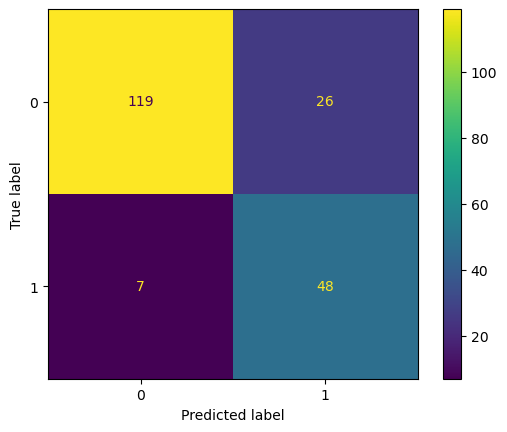

              precision    recall  f1-score   support

           0       0.94      0.82      0.88       145
           1       0.65      0.87      0.74        55

    accuracy                           0.83       200
   macro avg       0.80      0.85      0.81       200
weighted avg       0.86      0.83      0.84       200



In [29]:
#LDA fit and transform
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_smotetom, y_train_smotetom)
X_train_lda = lda.transform(X_train_smotetom)
X_test_lda = lda.transform(X_test)
# confusion matrix
cm = confusion_matrix(y_test, lda.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lda.classes_)
disp.plot()
plt.show()
# classification report
print(classification_report(y_test, lda.predict(X_test)))


#### Saving LDA _Smotetomek for Streamlit

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import joblib
from imblearn.combine import SMOTETomek
import pandas as pd

# Assuming you have your X_train and y_train DataFrames loaded

# Identify categorical and numerical features (make sure these are correct)
categorical_features = ['incident_type', 'collision_type', 'incident_severity',
                        'authorities_contacted', 'incident_state', 'property_damage',
                        'insured_hobbies']
numerical_features = ['vehicle_claim']

# Apply One-Hot Encoding to categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = encoder.fit_transform(X_train[categorical_features])
encoded_feature_names = encoder.get_feature_names_out(categorical_features)
X_encoded = pd.DataFrame(encoded_data, index=X_train.index, columns=encoded_feature_names)

# Apply Min-Max Scaling to numerical features
minmax_scaler = MinMaxScaler()
scaled_data = minmax_scaler.fit_transform(X_train[numerical_features])
X_scaled_numerical = pd.DataFrame(scaled_data, index=X_train.index, columns=numerical_features)

# Combine preprocessed features
X_processed = pd.concat([X_encoded, X_scaled_numerical], axis=1)

# Apply SMOTETomek for oversampling and undersampling
smote_tomek = SMOTETomek(random_state=42)
X_train_smotetom, y_train_smotetom = smote_tomek.fit_resample(X_processed, y_train)

# Train the LDA model
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_smotetom, y_train_smotetom)

# Save the *fitted* LDA model
joblib.dump(lda_model, 'lda_model.pkl')

# Save the *fitted* OneHotEncoder
joblib.dump(encoder, 'onehot_encoder.pkl')

# Save the *fitted* MinMaxScaler
joblib.dump(minmax_scaler, 'scaler.pkl')

print("LDA model, OneHotEncoder, and MinMaxScaler have been saved.")

# In your Streamlit app, you will load these saved files.

KeyError: "None of [Index(['incident_type', 'collision_type', 'incident_severity',\n       'authorities_contacted', 'incident_state', 'property_damage',\n       'insured_hobbies'],\n      dtype='object')] are in the [columns]"